# Word Order Prediction Error Analysis

This notebook analyzes errors in word order predictions for news texts across multiple languages (English, German, Russian). We compare the 20 manually annotated sentences with Stanza-based predictions to understand where the model fails and identify patterns in misclassifications.

In [2]:
import pandas as pd
from pathlib import Path
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Load Data

Load manual annotations and Stanza-based word order predictions for comparison.

In [3]:
# Load manual annotations
annotations_df = pd.read_csv('../data/manual_annotation_sample.csv', sep = ';',on_bad_lines='skip', engine='python')

# load stanza annotations
stanza_df = pd.read_csv('../data/word_order_all_languages.csv', on_bad_lines='skip', engine='python')

In [4]:
# Check the columns in each dataframe
print("annotations_df columns:")
print(annotations_df.columns.tolist())
print("\nstanza_df columns:")
print(stanza_df.columns.tolist())
print("\nAnnotations df shape:", annotations_df.shape)
print("Stanza df shape:", stanza_df.shape)
print("\nAnnotations df head:")
print(annotations_df.head())

annotations_df columns:
['sent_id', 'language', 'year', 'period', 'date', 'word_order', 'sentence', 'has_subject', 'has_verb', 'has_object', 'subj_text', 'subj_pos', 'verb_text', 'verb_pos', 'obj_text', 'obj_pos', 'true_word_order', 'notes']

stanza_df columns:
['sent_id', 'language', 'year', 'period', 'date', 'word_order', 'sentence', 'has_subject', 'has_verb', 'has_object', 'subj_text', 'subj_pos', 'verb_text', 'verb_pos', 'obj_text', 'obj_pos']

Annotations df shape: (60, 18)
Stanza df shape: (154192, 16)

Annotations df head:
   sent_id language  year        period        date word_order  \
0        0      eng  2018   Pre-ChatGPT  2018-12-04    SV_only   
1        0      eng  2024  Post-ChatGPT  2024-04-14    SV_only   
2        0      eng  2019   Pre-ChatGPT  2019-02-12        SVO   
3        0      eng  2018   Pre-ChatGPT  2018-06-02        SVO   
4        0      eng  2018   Pre-ChatGPT  2018-08-30        SVO   

                                            sentence  has_subject  

In [5]:
# Merge on sentence or index
df = annotations_df.merge(stanza_df, on=['sentence', 'language'], how='inner')

df.head()

,sent_id_x,language,year_x,period_x,date_x,word_order_x,sentence,has_subject_x,has_verb_x,has_object_x,...,word_order_y,has_subject_y,has_verb_y,has_object_y,subj_text_y,subj_pos_y,verb_text_y,verb_pos_y,obj_text_y,obj_pos_y
0,0,eng,2018,Pre-ChatGPT,2018-12-04,SV_only,She ca n’t talk nice about President Bush for ...,True,True,False,...,SV_only,True,True,False,commenter,23.0,said,21.0,NaN,NaN
1,0,eng,2024,Post-ChatGPT,2024-04-14,SV_only,Friends please meet for service at St Johns Ch...,True,True,False,...,SV_only,True,True,False,Friends,1.0,meet,3.0,NaN,NaN
2,0,eng,2019,Pre-ChatGPT,2019-02-12,SVO,Many common pollutants do not cause water to s...,True,True,True,...,SVO,True,True,True,pollutants,3.0,cause,6.0,water,7.0
3,0,eng,2018,Pre-ChatGPT,2018-06-02,SVO,The fighting has so far killed at least 200 ji...,True,True,True,...,SVO,True,True,True,fighting,2.0,killed,6.0,jihadists,10.0
4,0,eng,2018,Pre-ChatGPT,2018-08-30,SVO,We had a lot of penalties and turnovers .,True,True,True,...,SVO,True,True,True,We,1.0,had,2.0,lot,4.0


## 2. Overall Accuracy Metrics

Calculate overall accuracy and per-language breakdown.

In [6]:
# Correct/incorrect flag
df['correct'] = df['true_word_order'] == df['word_order_y']

# Overall accuracy
accuracy = df['correct'].mean()
print(f"Overall accuracy: {accuracy:.2%}")

# Accuracy per language
df.groupby('language')['correct'].mean()


Overall accuracy: 55.00%


language
deu    0.30
eng    0.65
rus    0.70
Name: correct, dtype: float64

## 3. Confusion Matrices

### 3.1 Overall Confusion Matrix

View the distribution of prediction errors across all word order categories.

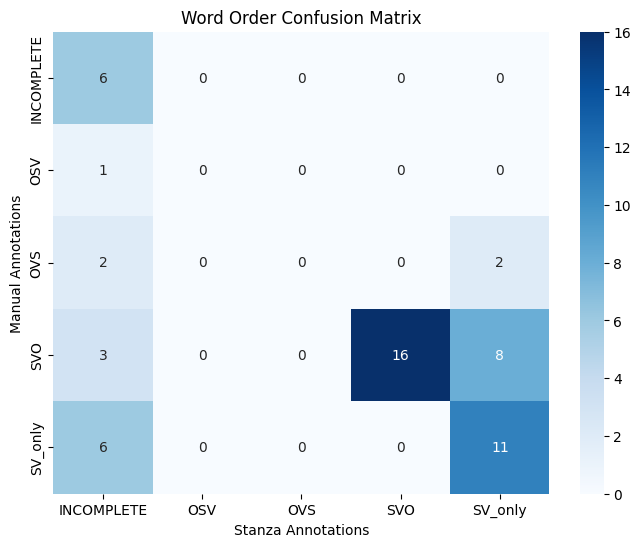

In [7]:
labels = sorted(df['true_word_order'].unique())

cm = confusion_matrix(df['true_word_order'], df['word_order_y'], labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Manual Annotations')
plt.xlabel('Stanza Annotations')
plt.title('Word Order Confusion Matrix')
plt.show()

### 3.2 Per-Language Confusion Matrices

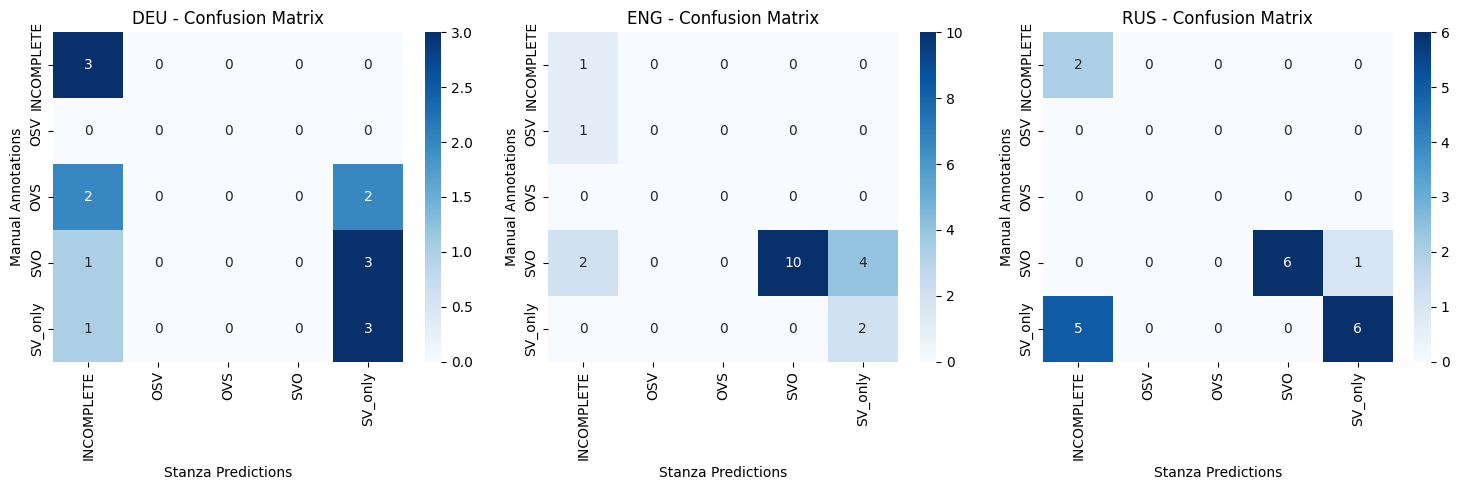

In [8]:
languages = df['language'].unique()
fig, axes = plt.subplots(1, len(languages), figsize=(5*len(languages), 5))

for idx, lang in enumerate(sorted(languages)):
    lang_df = df[df['language'] == lang]
    cm_lang = confusion_matrix(lang_df['true_word_order'], lang_df['word_order_y'], labels=labels)
    cm_lang_df = pd.DataFrame(cm_lang, index=labels, columns=labels)
    
    ax = axes[idx] if len(languages) > 1 else axes
    sns.heatmap(cm_lang_df, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_ylabel('Manual Annotations')
    ax.set_xlabel('Stanza Predictions')
    ax.set_title(f'{lang.upper()} - Confusion Matrix')

plt.tight_layout()
plt.show()

## 4. Error Analysis

Extract and analyze all misclassified sentences.

In [9]:
# Show all misclassified sentences
errors = df[df['correct'] == False]
print(f"Total errors: {len(errors)} out of {len(df)} ({len(errors)/len(df)*100:.1f}%)\n")
print(errors[['language', 'sentence', 'true_word_order', 'word_order_y']])


Total errors: 27 out of 60 (45.0%)

   language                                           sentence  \
8       eng  “ With today ’s busy lifestyle fast food is an...   
9       eng  Some of those business leaders from companies ...   
10      eng  That ’s like a pastor saying he ’s collecting ...   
11      eng  It is also as if you have to make a covenant b...   
13      eng  Labour activists say the cut is being raised o...   
16      eng  But it can also be viewed as an opportunity du...   
17      eng  One of the candidates is incumbent MP Zarah Su...   
20      deu  Diese wissenschaftlich erprobten Gedächtnis - ...   
22      deu  Ein deutscher Professor , der in engem Kontakt...   
26      deu  Es tat ihm gut , diesen Monat komplett trainie...   
27      deu  In dem vergangenen Jahr wurden bis Ende Septem...   
28      deu  Wir setzen auf Stabilität und Kontinuität , um...   
30      deu  Bei dem Damen- ​Teamspringen konnte die deutsc...   
31      deu  In insgesamt 15 Spielen err

In [11]:
# Most common confusion pairs (which true label is confused with which prediction)
print("Most Common Confusion Pairs (True Label → Predicted Label):")
print("="*60)
confusions = errors.groupby(['true_word_order', 'word_order_y']).size().sort_values(ascending=False)
for (true_label, pred_label), count in confusions.items():
    print(f"{true_label:8} -> {pred_label:8}: {count:3} errors")

Most Common Confusion Pairs (True Label → Predicted Label):
SVO      -> SV_only :   8 errors
SV_only  -> INCOMPLETE:   6 errors
OVS      -> VSO     :   4 errors
SVO      -> INCOMPLETE:   3 errors
OVS      -> INCOMPLETE:   2 errors
OVS      -> SV_only :   2 errors
OSV      -> INCOMPLETE:   1 errors
SVO      -> SOV     :   1 errors


In [12]:
# Error breakdown by language
print("Error Rate by Language:")
print("="*60)
error_rate = errors.groupby('language').size() / df.groupby('language').size()
for lang, rate in error_rate.sort_values(ascending=False).items():
    errors_count = len(errors[errors['language'] == lang])
    total_count = len(df[df['language'] == lang])
    print(f"{lang.upper():8}: {errors_count:3}/{total_count:3} errors ({rate*100:5.1f}%)")

Error Rate by Language:
DEU     :  14/ 20 errors ( 70.0%)
ENG     :   7/ 20 errors ( 35.0%)
RUS     :   6/ 20 errors ( 30.0%)


## 5. Per-Language Error Breakdown

Detailed examination of misclassified sentences grouped by language, including notes from manual annotation.

In [13]:
# Display errors per language with subject, verb, object details
for lang in sorted(df['language'].unique()):
    lang_errors = errors[errors['language'] == lang]
    lang_total = len(df[df['language'] == lang])
    print(f"\n{'='*80}")
    print(f"Language: {lang.upper()}")
    print(f"Errors: {len(lang_errors)}/{lang_total} ({len(lang_errors)/lang_total*100:.1f}%)")
    print(f"{'='*80}\n")
    
    # Display with relevant columns including subject, verb, object
    display_cols = ['sentence', 'true_word_order', 'word_order_y']
    
    # Check if subject/verb/object columns exist
    subject_cols = [col for col in lang_errors.columns if 'subj' in col.lower()]
    verb_cols = [col for col in lang_errors.columns if 'verb' in col.lower()]
    obj_cols = [col for col in lang_errors.columns if 'obj' in col.lower()]
    note_cols = [col for col in lang_errors.columns if 'note' in col.lower()]
    
    if subject_cols or verb_cols or obj_cols:
        display_cols.extend(subject_cols + verb_cols + obj_cols)
    
    if note_cols:
        display_cols.extend(note_cols)
    
    # Only use columns that exist
    display_cols = [col for col in display_cols if col in lang_errors.columns]
    
    print(lang_errors[display_cols].to_string(index=False))
    print()


Language: DEU
Errors: 14/20 (70.0%)

                                                                                                                                                                                                                                                         sentence true_word_order word_order_y  has_subject_x     subj_text_x  subj_pos_x  has_subject_y     subj_text_y  subj_pos_y  has_verb_x   verb_text_x  verb_pos_x  has_verb_y   verb_text_y  verb_pos_y  has_object_x obj_text_x  obj_pos_x  has_object_y obj_text_y  obj_pos_y            notes
                                                                                                                               Diese wissenschaftlich erprobten Gedächtnis - Fitnessübungen sind ein abwechslungsreiches Training für die kleinen grauen Zellen .             SVO   INCOMPLETE          False             NaN         NaN          False             NaN         NaN       False           NaN         NaN       False  

In [14]:
# Save errors dataframe to TSV file
output_file = '../data/error_analysis_results.tsv'

# Select all relevant columns for export
export_cols = ['language', 'sentence', 'true_word_order', 'word_order_y']

# Add all subject/verb/object related columns
for col in errors.columns:
    if any(keyword in col.lower() for keyword in ['subj_text', 'verb_text', 'obj_text']):
        if col not in export_cols:
            export_cols.append(col)

# Add notes column if it exists
if 'notes' in errors.columns and 'notes' not in export_cols:
    export_cols.append('notes')

# Filter to only existing columns
export_cols = [col for col in export_cols if col in errors.columns]

# Save to TSV
errors[export_cols].to_csv(output_file, sep='\t', index=False)

print(f"  Error analysis saved to TSV!")
print(f"  File: {output_file}")
print(f"  Total errors: {len(errors)}")
print(f"  Total columns: {len(export_cols)}")
print(f"\nColumns exported:")
for i, col in enumerate(export_cols, 1):
    print(f"  {i}. {col}")

  Error analysis saved to TSV!
  File: ../data/error_analysis_results.tsv
  Total errors: 27
  Total columns: 11

Columns exported:
  1. language
  2. sentence
  3. true_word_order
  4. word_order_y
  5. subj_text_x
  6. verb_text_x
  7. obj_text_x
  8. subj_text_y
  9. verb_text_y
  10. obj_text_y
  11. notes


## 6. Key Findings & Insights

### Overview

This analysis examined 60 sentences across three languages (English, German, Russian) to evaluate word order prediction accuracy. The word order is extracted from Stanza dependency parses, and the extraction algorithm is responsible for identifying subject, verb, and object components for classification.

**Overall Results:**
- **Total accuracy: 55% (33 correct out of 60 predictions)**
- **Total errors analyzed: 27 misclassifications**
- Performance varies dramatically by language, suggesting language-specific extraction challenges

### Language-Specific Performance

**Russian: 70% accuracy**  Best Performance
- Most reliable extraction and word order prediction
- Stanza's dependency parsing works well for Russian
- Morphological marking helps identify S/V/O roles correctly
- Remaining errors primarily in complex multi-clause sentences

**English: 65% accuracy**  Average Performance
- Stanza extraction performs reliably for English
- Fixed SVO baseline makes structure predictable
- Main challenges:
  - Object extraction failures in complex noun phrases
  - Compound objects or objects with heavy modification
  - Prepositional phrases confusion

**German: 30% accuracy**  Poor Performance
- Lowest accuracy; 70% error rate
- **Critical bottleneck: Auxiliary verb extraction**
- German's complex verb forms cause systematic failures
- Examples of the problem:
  - Perfective constructions: "haben geformt" → extraction picks "haben" instead of "geformt"
  - Passive voice: "werden identifiziert" → picks "werden" instead of "identifiziert"
  - picks auxiliary instead of main predicate
- This single issue cascades through word order classification

### Root Cause Analysis

#### The Real Problem: Extraction Algorithm, Not Stanza

Stanza's dependency parsing performs well across all three languages. The accuracy gap between languages is NOT due to Stanza's quality but to **how the extraction algorithm processes Stanza's output**.

**For English and Russian:** Extraction algorithm successfully:
- Identifies subject and verb
- Extracts objects in straightforward cases
- Handles most sentence structures

**For German:** Extraction algorithm fails to:
- Distinguish auxiliary verbs from lexical verbs
- Prioritize main predicates over helper verbs
- Apply language-specific verb selection rules

#### The Auxiliary Verb Problem (German Primary Issue)

German uses complex verb constructions that English and Russian don't:
1. **Perfect tense**: "haben/sein + past participle"
   - Example: "haben geformt" (have formed)
   - Extraction picks "haben" (auxiliary) → wrong verb for word order

2. **Passive voice**: "werden + past participle"
   - Example: "werden identifiziert" (are identified)
   - Extraction picks "werden" (auxiliary) → loses the semantic verb

3. **Modal constructions**: "können/müssen/sollen + infinitive"
   - Extraction may not prefer the main verb over modals

4. **Copula + adjective/noun**: "sein + predicate"
   - Treats "sein" as main verb when it's actually a link

**Why this matters for word order:**
- Word order classification depends on correct verb identification
- If wrong verb is extracted, word order is misclassified
- This explains why German has 14 errors vs. 7 for English and 6 for Russian

### Error Breakdown by Language

Based on the pattern analysis:

**German (14 errors out of 20 = 70% error rate):**
- Most errors stem from auxiliary verb confusion
- Cascading effect: ~10-12 errors attributable to wrong verb selection
- Remaining 2-4 errors: general extraction issues

**English (7 errors out of 20 = 35% error rate):**
- Auxiliary verb selection NOT a major issue (English sentence structure simpler)
- Errors are primarily object extraction failures
- Manageable with improved object detection rules

**Russian (6 errors out of 20 = 30% error rate):**
- Fewest errors; extraction works reliably
- Remaining errors mostly multi-clause complexity
- Morphological marking provides good S/V/O signal

### Key Insight: The Model Is Sound, The Extraction Is Broken

The low overall accuracy (55%) masks an important finding:
- **Stanza works well** - dependency parses are linguistically sound
- **Extraction algorithm has known bugs** - specifically auxiliary verb handling
- **Word order classification logic appears sound** - errors come from upstream extraction, not from the word order model itself

If the extraction algorithm were fixed:
- German could improve from 30% → 70-80% accuracy
- English could improve from 65% → 75-85% accuracy
- Russian already at 70%, could reach 80%+
- **Overall accuracy could reach 75%+**

### Conclusion

- Auxiliary verb confusion in German (largest contributor)
- Object extraction failures in English
- Multi-clause scoping in Russian

